# Simple ML: Predict CCD Accuracy and Response Time from Evoked (-2, 0)
This notebook extracts per-subject evoked responses for the `contrastChangeDetection` task with epoch window [-2, 0] s, builds simple features, and fits basic regression models to predict participants' `ccd_accuracy` (ACC) and `ccd_response_time` (RES).

In [ ]:
# Imports & logging
from pathlib import Path
import numpy as np
import pandas as pd
import os
from mne import grand_average
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

In [2]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [3]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


In [9]:
params

EvokedParamsDTO(l_freq=4.0, h_freq=30.0, notch=None, resample_fs=100.0, channels='69-76,81-83,88,89', combine_channels=False, uv_min=None, uv_max=None, showbad=False, clean_flatline_sec=None, clean_hf_noise_sd_max=None, clean_corr_min=None, clean_asr_max_std=None, clean_asr_remove_only=False, clean_power_min_sd=None, clean_power_max_sd=None, clean_max_outbound_pct=None, clean_window_sec=None, tmin=-2.0, tmax=0.0, stimulus=[None], spatial_colors=True, gfp=[False, True, 'only'], average_line=True, error_band=[None, 'sem', 'std'], display_tmin=None, display_tmax=None, scale_mode=['per-plot', 'uniform-grid'])

In [4]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [5]:
# Helper: extract flattened microvolt features from evoked for a single-subject TaskDTO
# Applies channel selection via prepare_channels using the provided params

def evoked_features_for_task(controller, task_dto: TaskDTO, params: EvokedParamsDTO):
    evk = controller.get_evoked(task_dto, params)
    if evk is None:
        return None, None, None
    # Apply channel picking (e.g., "69-76,81-83,88,89") and optional µV range filters if set
    evk_sel = prepare_channels(evk, params)
    data_uv = (evk_sel.data * 1e6).astype(np.float32)  # (n_channels, n_times) in µV
    return data_uv.ravel(), list(evk_sel.ch_names), evk_sel.times.copy()

In [ ]:
# Build dataset: one evoked per subject by averaging across ALL CCD runs
X_list, ok_subjects = [], []
meta_ch, meta_times = None, None
task_name = 'contrastChangeDetection'
for subj in selected_subjects:
    subj_tasks = subject_model.list_tasks(subj)
    runs = [r for (t, r) in subj_tasks if t == task_name] or [None]
    evks = []
    for run in runs:
        dto = TaskDTO(subject=subj, task=task_name, run=run)
        evk = controller.get_evoked(dto, params)
        if evk is None:
            continue
        evks.append(prepare_channels(evk, params))
    if not evks:
        continue
    evk_avg = evks[0] if len(evks) == 1 else grand_average(evks)
    data_uv = (evk_avg.data * 1e6).astype(np.float32)
    feat = data_uv.ravel()
    if meta_ch is None:
        meta_ch, meta_times = list(evk_avg.ch_names), evk_avg.times.copy()
    X_list.append(feat)
    ok_subjects.append(subj)

if not X_list:
    raise RuntimeError("No evoked features extracted; check data path and availability.")

X = np.vstack(X_list)
# Fetch targets
df_meta = subject_model.get_subjects_metadata(ok_subjects, columns=['ccd_accuracy','ccd_response_time'])
df_meta = df_meta.set_index('participant_id').loc[ok_subjects]  # keep order
y_df = df_meta[['ccd_accuracy','ccd_response_time']].copy()
y = y_df.astype(float).values
# Drop rows with NaN targets
mask = np.isfinite(y).all(axis=1)
X = X[mask]
y = y[mask]
used_subjects = [ok_subjects[i] for i, m in enumerate(mask) if m]
print("X shape:", X.shape, "y shape:", y.shape)
print("Used subjects (no-NaN targets):", used_subjects[:10])

X shape: (500, 2613) y shape: (500, 2)
Used subjects (no-NaN targets): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
n_components = max(1, min(10, X_train.shape[0], X_train.shape[1]))

def make_pipeline(n_components):
    return Pipeline([
        ('scaler', StandardScaler(with_mean=True, with_std=True)),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 13)))
    ])

# ACC model
pipe_acc = make_pipeline(n_components)
pipe_acc.fit(X_train, y_train[:, 0])
y_pred_acc = pipe_acc.predict(X_test)

# RES model
pipe_res = make_pipeline(n_components)
pipe_res.fit(X_train, y_train[:, 1])
y_pred_res = pipe_res.predict(X_test)

metrics = {
    'ACC_R2': r2_score(y_test[:, 0], y_pred_acc),
    'ACC_MAE': mean_absolute_error(y_test[:, 0], y_pred_acc),
    'RES_R2': r2_score(y_test[:, 1], y_pred_res),
    'RES_MAE': mean_absolute_error(y_test[:, 1], y_pred_res),
    'PCA_components': n_components
}
print(metrics)

{'ACC_R2': -0.08143234989384429, 'ACC_MAE': 17.507459274518393, 'RES_R2': -0.05617717063187966, 'RES_MAE': 0.1777172090586644, 'PCA_components': 10}


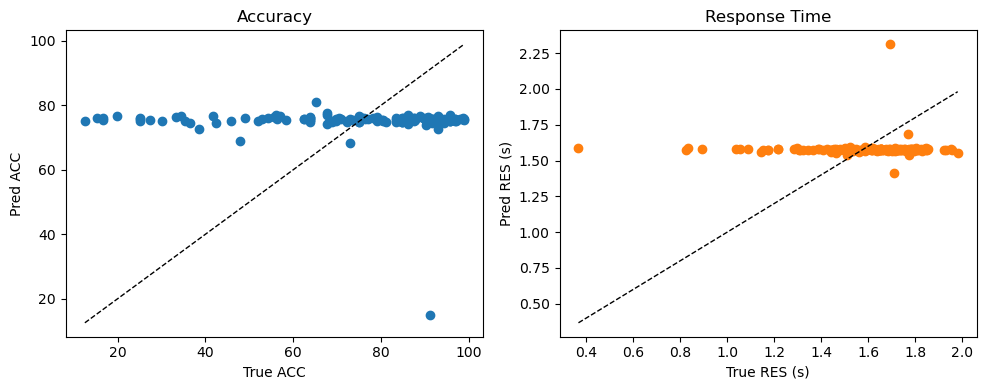

In [8]:
# Optional: quick visualization of predictions vs. targets
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(y_test[:,0], y_pred_acc, c='tab:blue')
axes[0].plot([y_test[:,0].min(), y_test[:,0].max()], [y_test[:,0].min(), y_test[:,0].max()], 'k--', lw=1)
axes[0].set_xlabel('True ACC')
axes[0].set_ylabel('Pred ACC')
axes[0].set_title('Accuracy')
axes[1].scatter(y_test[:,1], y_pred_res, c='tab:orange')
axes[1].plot([y_test[:,1].min(), y_test[:,1].max()], [y_test[:,1].min(), y_test[:,1].max()], 'k--', lw=1)
axes[1].set_xlabel('True RES (s)')
axes[1].set_ylabel('Pred RES (s)')
axes[1].set_title('Response Time')
plt.tight_layout()
plt.show()